Connecting to Gold Layer (PostgreSQL)...


/tmp/ipykernel_839/2819015883.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_viz = pd.read_sql(query, conn)
/tmp/ipykernel_839/2819015883.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


[SUCCESS] Data loaded for visualization!


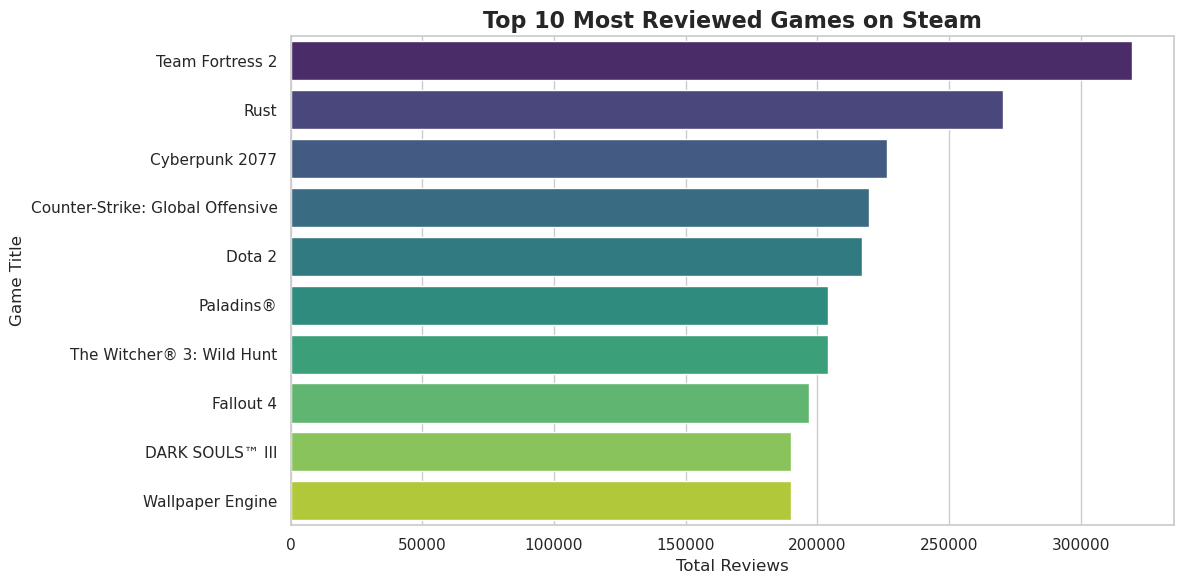

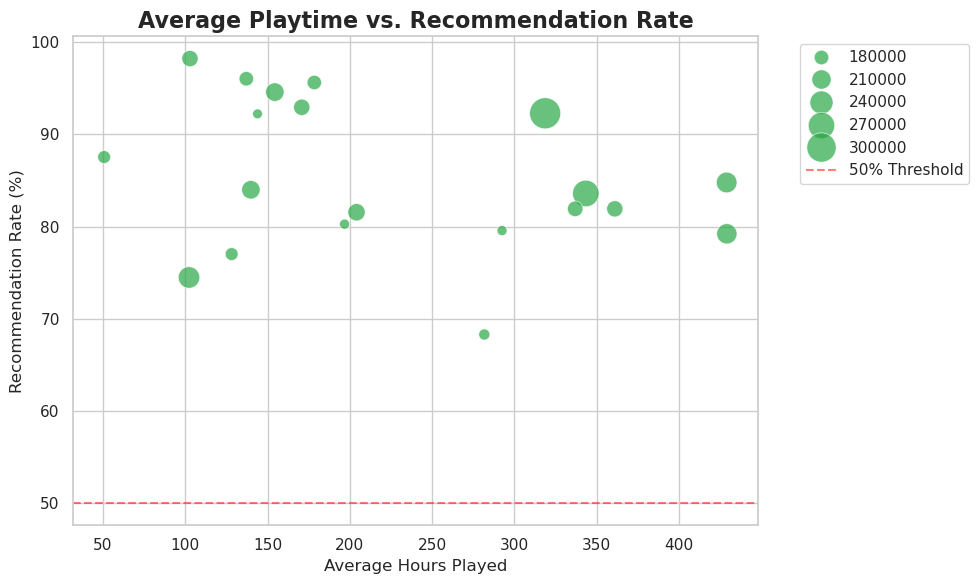

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Connecting to Gold Layer (PostgreSQL)...")

DB_PARAMS = {
    "host": "postgres-db",
    "database": "steam_analytics",
    "user": "admin",
    "password": "admin"
}

try:
    conn = psycopg2.connect(**DB_PARAMS)
    query = """
    SELECT title, total_reviews, avg_hours_played, recommendation_rate 
    FROM game_insights 
    ORDER BY total_reviews DESC 
    LIMIT 20;
    """
    df_viz = pd.read_sql(query, conn)
    conn.close()
    print("[SUCCESS] Data loaded for visualization!")
    
    sns.set_theme(style="whitegrid")
#Top 10 Most Reviewed Games  
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_viz.head(10), 
        x="total_reviews", 
        y="title", 
        palette="viridis"
    )
    plt.title("Top 10 Most Reviewed Games on Steam", fontsize=16, fontweight='bold')
    plt.xlabel("Total Reviews", fontsize=12)
    plt.ylabel("Game Title", fontsize=12)
    plt.tight_layout()
    plt.show()
#ScatterPlot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_viz, 
        x="avg_hours_played", 
        y="recommendation_rate", 
        size="total_reviews", 
        sizes=(50, 500),
        alpha=0.7,
        color="#28a745"
    )
    plt.title("Average Playtime vs. Recommendation Rate", fontsize=16, fontweight='bold')
    plt.xlabel("Average Hours Played", fontsize=12)
    plt.ylabel("Recommendation Rate (%)", fontsize=12)
    plt.axhline(50, color='red', linestyle='--', alpha=0.5, label="50% Threshold")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"[ERROR] {e}")